# 01 · Baseline single-model QA  (Phase 1 MVP)

**Who Wants to Be a PoliMillionaire?** — the first answering pipeline, this notebook is.

What it does: clone the repo, load Qwen2.5-7B in 4-bit, wire the QA pipeline
(classify -> prompt -> generate -> parse), run it over a small hand-checked dev question set,
and report **accuracy + latency**. The live game, we touch NOT here — offline measurement only,
so the 30s timer we never start by accident.

Pipeline parts, all from `src/` imported they are (built modularly, they were):
`TransformersEngine` · `QuestionClassifier` · `PromptBuilder.zero_shot_v1` · `QAPipeline` ·
`BenchmarkRunner` + `metrics`.

> **GPU needed.** Runtime ▸ Change runtime type ▸ T4 GPU, select you must.

## 1 · Setup — clone the repo + install deps
From GitHub the code we pull (no Drive needed). A private repo it is? Then make it public, or a token use you must.

In [1]:
import os, sys

# The repo, into Colab we clone -- present already? Then update it instead, we do.
REPO_URL = 'https://github.com/SleepyEveryD/NLP.git'
REPO_ROOT = '/content/NLP'
if not os.path.exists(REPO_ROOT):
    !git clone {REPO_URL} {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull -q

# The src tree, onto the import path it goes.
SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

# Into the repo root, change directory we do -- relative paths simpler they become.
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)
print('On sys.path:', SRC)

# The dev set, present it must be (un-ignored in git it now is).
assert os.path.exists('data/dev_questions.jsonl'), 'Missing the dev set -- pushed data/dev_questions.jsonl, did you?'

Cloning into '/content/NLP'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 169 (delta 3), reused 22 (delta 3), pack-reused 140 (from 1)
Receiving objects: 100% (169/169), 44.58 MiB | 22.04 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Repo root: /content/NLP
On sys.path: /content/NLP/src


In [2]:
# The Phase-1 inference stack, install we do -- light it stays (RAG deps, in Phase 4 they come).
!pip install -q 'transformers>=4.45.0' 'accelerate>=0.34.0' 'bitsandbytes>=0.43.0' sentencepiece einops pyyaml pandas matplotlib
print('Installed, the Phase-1 dependencies are.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.4 MB/s eta 0:00:00
Installed, the Phase-1 dependencies are.


In [3]:
import torch

# A GPU, present it must be -- on CPU, a 7B model in 30s answer we cannot.
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING -- no GPU. Runtime ▸ Change runtime type ▸ T4 GPU, switch you must.')

CUDA available: True
GPU: Tesla T4


## 2 · Load the run config
Into every run logged it is (D-007) — reproducible, the science stays.

In [4]:
from config import RunConfig

# The base config, from YAML we load.
config = RunConfig.from_yaml(os.path.join(REPO_ROOT, 'configs', 'base.yaml'))
print('run_id:', config.run_id)
print('model:', config.model.name, '|', config.model.quantization, '|', config.model.dtype)
print('latency budget:', config.latency_budget_s, 's')
print('prompt strategy:', config.prompt_strategy)

run_id: baseline
model: Qwen/Qwen2.5-7B-Instruct | 4bit | bfloat16
latency budget: 30.0 s
prompt strategy: zero_shot_v1


## 3 · Load + warm up the model
On a T4, ~1–2 minutes the 4-bit load takes (a one-time cost). Warmup pays the first-call latency
**before** any question is timed — so the 30s budget, a cold start never eats it.

In [5]:
import time
from inference.engine import TransformersEngine

# Once, the model we load -- the cold-start cost, here we pay it.
t0 = time.perf_counter()
engine = TransformersEngine(
    model_name=config.model.name,
    quantization=config.model.quantization,
    dtype=config.model.dtype,
)
load_s = time.perf_counter() - t0
print(f'Model loaded in {load_s:.1f}s')

# Warm up -- the first-call kernels, compiled before any timed question they are.
t0 = time.perf_counter()
engine.warmup()
warm_s = time.perf_counter() - t0
print(f'Warmup in {warm_s:.1f}s')

# A smoke generation -- the answering path works, confirm we do.
t0 = time.perf_counter()
out = engine.generate('Reply with the single letter B and nothing else.', max_new_tokens=5)
gen_s = time.perf_counter() - t0
print(f'Smoke generate in {gen_s:.2f}s -> {out!r}')
print(f'tokens_in={engine.last_tokens_in}, tokens_out={engine.last_tokens_out}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model loaded in 252.5s
Warmup in 1.5s
Smoke generate in 0.64s -> 'B'
tokens_in=39, tokens_out=2


## 4 · Wire the pipeline + a single-question demo
Dependency injection (D-006): engine, classifier and prompt builder, injected they are.
RAG and tools, off for the baseline they stay (Phase 4 and Phase 3 turn them on).

In [6]:
from classify.classifier import QuestionClassifier
from prompting.builder import PromptBuilder
from agent.pipeline import QAPipeline
from evaluation.dataset import load_questions

# The collaborators, injected into the pipeline they are (D-006).
classifier = QuestionClassifier()
prompt_builder = PromptBuilder(strategy=config.prompt_strategy)
pipeline = QAPipeline(
    engine=engine,
    prompt_builder=prompt_builder,
    classifier=classifier,
    retriever=None,   # Off for the baseline -- Phase 4 turns it on.
    tools=None,       # Off for the baseline -- Phase 3 turns it on.
    latency_budget_s=config.latency_budget_s,
)

# The dev question set, from disk loaded it is.
questions = load_questions(os.path.join(REPO_ROOT, 'data', 'dev_questions.jsonl'))
print(f'Loaded {len(questions)} dev questions.')

# One question, end to end through the pipeline we run -- the moving parts, inspect them we do.
demo_q = questions[0]
enriched = classifier.classify(demo_q)
print('--- The built prompt ---')
print(prompt_builder.build(enriched))
print()
pred = pipeline.answer(demo_q)
print('--- The prediction ---')
print('raw_output:', repr(pred.raw_output))
print('parsed answer:', pred.answer, '| gold:', demo_q.gold, '| confidence:', pred.confidence)
print('latency_s:', round(pred.latency_s, 2), '| tokens_out:', pred.tokens_out)

Loaded 23 dev questions.
--- The built prompt ---
Question: Which planet in our solar system has the most moons?
A) Jupiter
B) Saturn
C) Uranus
D) Neptune
Reply with ONLY the letter of the correct option (A, B, C, or D). No explanation, no punctuation -- the letter alone.

--- The prediction ---
raw_output: 'A'
parsed answer: A | gold: B | confidence: 1.0
latency_s: 0.97 | tokens_out: 2


## 5 · Run the baseline benchmark
Over all dev questions the pipeline runs; one `EvalRecord` per question, to JSONL it is logged (D-007).
Crash-safe it is — each line flushed immediately, so a Colab disconnect nothing it loses.

In [7]:
from evaluation.runner import BenchmarkRunner

# Into the repo the run logs we write.
runner = BenchmarkRunner(
    pipeline=pipeline,
    config=config,
    log_root=os.path.join(REPO_ROOT, 'experiments', 'runs'),
)
run_path = runner.run(questions)
print('Run written to:', run_path)

[1/23] qid=dev-001 ...
[2/23] qid=dev-002 ...
[3/23] qid=dev-003 ...
[4/23] qid=dev-004 ...
[5/23] qid=dev-005 ...
[6/23] qid=dev-006 ...
[7/23] qid=dev-007 ...
[8/23] qid=dev-008 ...
[9/23] qid=dev-009 ...
[10/23] qid=dev-010 ...
[11/23] qid=dev-011 ...
[12/23] qid=dev-012 ...
[13/23] qid=dev-013 ...
[14/23] qid=dev-014 ...
[15/23] qid=dev-015 ...
[16/23] qid=dev-016 ...
[17/23] qid=dev-017 ...
[18/23] qid=dev-018 ...
[19/23] qid=dev-019 ...
[20/23] qid=dev-020 ...
[21/23] qid=dev-021 ...
[22/23] qid=dev-022 ...
[23/23] qid=dev-023 ...
Run written to: /content/NLP/experiments/runs/baseline


## 6 · Results — accuracy + latency
From the JSONL log all of it derives — re-analyse without re-running the model, we can.

In [8]:
from evaluation.metrics import load_runs, accuracy_by, latency_summary

# The logged run, back into a DataFrame we read.
df = load_runs([run_path])

# Overall accuracy, the headline number it is.
known = df[df['correct'].notna()]
overall = known['correct'].astype(float).mean()
print(f'Overall accuracy: {overall:.1%}  (n={len(known)})')
print()
print('--- Accuracy by topic ---')
print(accuracy_by(df, 'topic').to_string(index=False))
print()
print('--- Accuracy by level ---')
print(accuracy_by(df, 'level').to_string(index=False))
print()
print('--- Latency summary (seconds) ---')
for k, v in latency_summary(df).items():
    print(f'{k}: {v}')

Overall accuracy: 87.0%  (n=23)

--- Accuracy by topic ---
                       topic  accuracy  n
Ancient History and Politics      1.00  4
               Entertainment      1.00  4
                       Maths      0.50  4
                        News      1.00  4
   Philosophy and Psychology      1.00  3
          Science and Nature      0.75  4

--- Accuracy by level ---
 level  accuracy  n
     1  1.000000  1
     2  1.000000  4
     3  0.800000  5
     4  1.000000  3
     5  0.800000  5
     6  0.666667  3
     7  1.000000  1
     8  1.000000  1

--- Latency summary (seconds) ---
median_s: 0.9095702419999725
p95_s: 1.0133455697998897
max_s: 1.050432285999932
mean_s: 0.9193495519130505
over_budget: 0
budget_violation_rate: 0.0


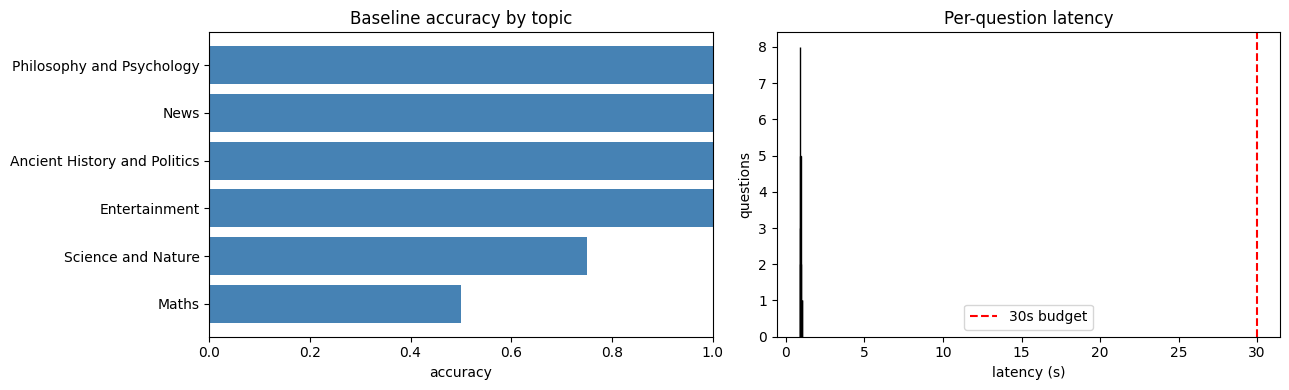

In [9]:
import matplotlib.pyplot as plt

# Accuracy by topic, a bar chart it becomes -- per-topic strengths, the rubric asks for them.
topic_acc = accuracy_by(df, 'topic').sort_values('accuracy')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh(topic_acc['topic'], topic_acc['accuracy'], color='steelblue')
ax[0].set_xlim(0, 1)
ax[0].set_xlabel('accuracy')
ax[0].set_title('Baseline accuracy by topic')

# Latency per question, a histogram it forms -- the 30s wall, a red line marks it.
ax[1].hist(df['latency_s'].dropna(), bins=12, color='darkorange', edgecolor='black')
ax[1].axvline(30.0, color='red', linestyle='--', label='30s budget')
ax[1].set_xlabel('latency (s)')
ax[1].set_ylabel('questions')
ax[1].set_title('Per-question latency')
ax[1].legend()
plt.tight_layout()
plt.show()

## 7 · Observations + next steps

_Fill these in after the run (they feed the investigation rubric):_

- **30s feasibility:** does median + p95 latency sit comfortably under 30s on a T4? (see the latency summary)
- **Per-topic strengths:** which of the 6 topics is strongest / weakest at baseline?
- **Overconfidence:** any wrong answers carrying high `confidence`? (a confidence-vs-correctness look)
- **Failure modes:** scan the `raw_output` of the misses — chatter the parser mishandled, or real knowledge gaps?

**Next (Phase 2 — prompt engineering):** add `few_shot_v1` and `cot_v1` to `PromptBuilder`, re-run the
same benchmark, and compare via `metrics`. Same pipeline seam, same logging — only the strategy changes.

> Note: the dev set is small (~23 hand-checked questions) and English-only — it measures the *pipeline*,
> not final leaderboard skill. Grow it before drawing strong conclusions.